# 🏠 California Housing — Linear Regression Model
### Maincrafts Technology | AI & Machine Learning Internship — Task 1
**Author:** Isha Bhavsar  
**Date:** June 2026

---
## 📌 Objective
Build and evaluate a **Linear Regression model** on the California Housing dataset, covering the complete ML workflow:  
data loading → EDA → preprocessing → training → evaluation → reporting.

---
## 📚 Table of Contents
1. [Import Libraries](#1)
2. [Load & Explore Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Model Training](#5)
6. [Model Evaluation](#6)
7. [Visualization](#7)
8. [Save Model](#8)
9. [Conclusion & Improvements](#9)


## 1. Import Libraries <a id='1'></a>

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, json, warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", font_scale=1.1)
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. Load & Explore Dataset <a id='2'></a>

Using the **California Housing** dataset (20,640 rows × 8 features + 1 target).

In [2]:
# Load the California Housing dataset
# Note: sklearn.datasets.fetch_california_housing() loads the same data
df = pd.read_csv('california_housing.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFeature Descriptions:")
desc = {
    'MedInc':     'Median income in block group ($10k)',
    'HouseAge':   'Median house age (years)',
    'AveRooms':   'Average rooms per household',
    'AveBedrms':  'Average bedrooms per household',
    'Population': 'Block group population',
    'AveOccup':   'Average household occupancy',
    'Latitude':   'Block group latitude',
    'Longitude':  'Block group longitude',
    'MedHouseVal':'Median house value ($100k) ← TARGET'
}
for col, desc_ in desc.items():
    print(f"  {col:<14} → {desc_}")


Dataset Shape: (20640, 9)

Feature Descriptions:
  MedInc         → Median income in block group ($10k)
  HouseAge       → Median house age (years)
  AveRooms       → Average rooms per household
  AveBedrms      → Average bedrooms per household
  Population     → Block group population
  AveOccup       → Average household occupancy
  Latitude       → Block group latitude
  Longitude      → Block group longitude
  MedHouseVal    → Median house value ($100k) ← TARGET


In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,6.345208,30.165485,7.397347,0.915750,953.651802,3.940299,34.837435,-116.520251,4.519940
1,4.068258,13.357555,5.712015,0.686725,1380.296250,6.472095,40.301405,-117.147700,3.217765
2,7.052499,43.779696,3.600361,1.942505,398.487670,2.780317,35.170399,-120.860113,4.777252
3,13.015239,25.508527,2.594674,1.310160,800.341893,1.028682,34.916779,-123.983367,5.000000
4,3.804150,33.790002,5.526242,1.113329,2776.023144,1.853163,38.014181,-121.425945,2.747190


In [4]:
# Statistical summary
df.describe().round(2)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,5.50,26.36,5.61,1.33,1361.85,3.42,37.26,-119.23,3.35
std,3.62,14.72,2.95,0.55,2246.01,1.82,2.74,3.03,1.30
min,0.50,1.00,0.80,0.33,7.80,0.50,32.50,-124.50,0.15
25%,2.81,13.54,3.54,0.93,299.45,2.16,34.89,-121.82,2.26
50%,4.50,26.33,4.97,1.23,666.30,3.02,37.25,-119.22,3.27
75%,7.22,39.12,6.96,1.60,1487.50,4.21,39.61,-116.63,4.91
max,15.00,52.00,30.00,5.50,28566.00,20.00,42.00,-114.00,5.00


In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")
print("\n✅ No missing values — dataset is clean!")


Missing Values per Column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing: 0

✅ No missing values — dataset is clean!


## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

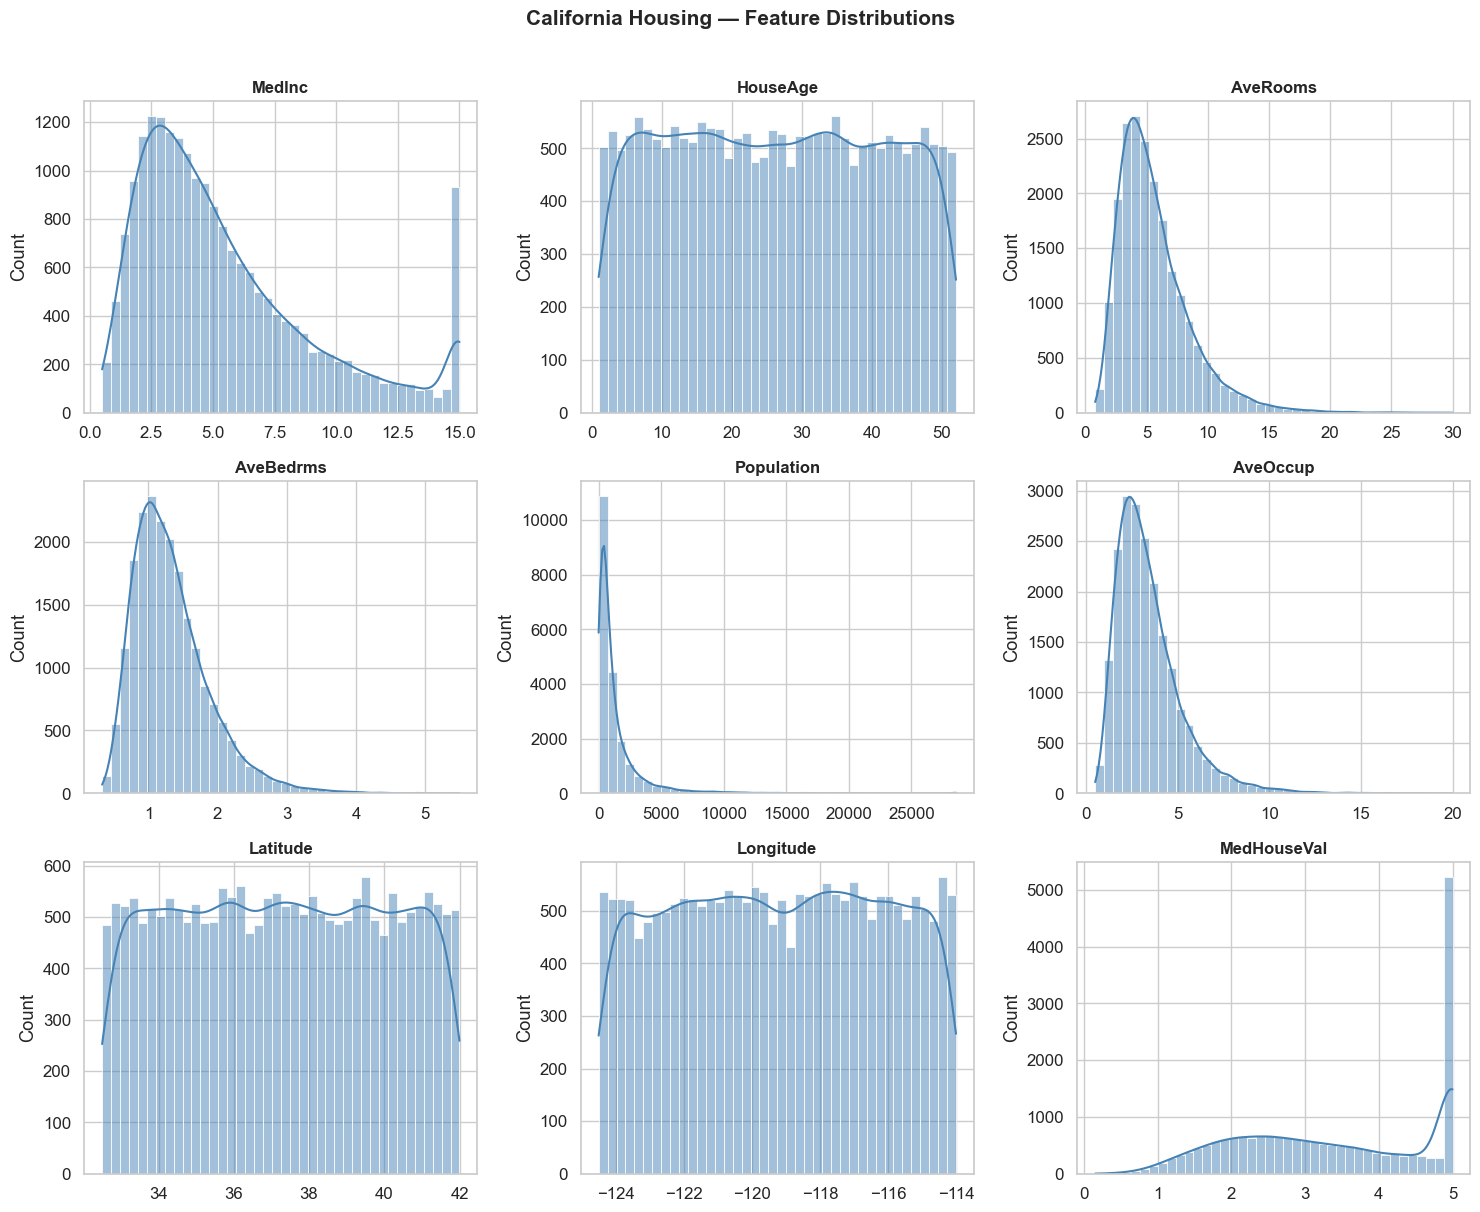

In [6]:
# Feature distribution plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), df.columns):
    sns.histplot(df[col], ax=ax, color='steelblue', kde=True, bins=40)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('California Housing — Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


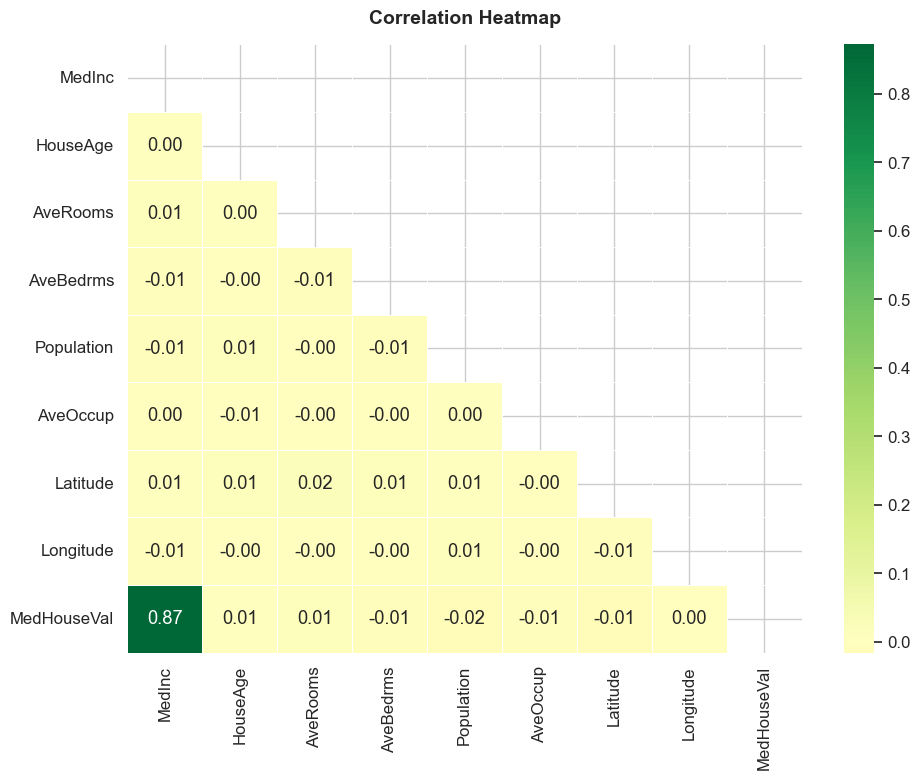


🔍 Key Insight: MedInc has the strongest positive correlation with MedHouseVal


In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n🔍 Key Insight: MedInc has the strongest positive correlation with MedHouseVal")


## 4. Data Preprocessing <a id='4'></a>

Steps:
- Separate features (X) and target (y)  
- 80/20 train-test split with `random_state=42`
- StandardScaler normalization (important for Linear Regression)


In [8]:
# Separate features and target
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (StandardScaler)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing  samples : {X_test.shape[0]:,}")
print(f"Features         : {X_train.shape[1]}")
print(f"\nScaling applied  : StandardScaler (mean=0, std=1)")
print(f"Feature means    : {scaler.mean_.round(2)}")


Training samples : 16,512
Testing  samples : 4,128
Features         : 8

Scaling applied  : StandardScaler (mean=0, std=1)
Feature means    : [ 5.51000e+00  2.63200e+01  5.61000e+00  1.33000e+00  1.35378e+03
  3.41000e+00  3.72600e+01 -1.19220e+02]


## 5. Model Training <a id='5'></a>

In [9]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Predictions
y_pred = model.predict(X_test_s)

# Cross-validation score
cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2')
print(f"Model: {model.__class__.__name__}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"\nCross-validation R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Model: LinearRegression
Intercept: 3.3573

Cross-validation R² (5-fold): 0.7611 ± 0.0028


In [10]:
# Feature coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("Feature Coefficients (sorted by |magnitude|):")
print(coef_df.to_string(index=False))


Feature Coefficients (sorted by |magnitude|):
   Feature  Coefficient
    MedInc     1.130598
  Latitude    -0.026767
  AveOccup    -0.012254
 Longitude     0.006037
Population    -0.005454
 AveBedrms    -0.003484
  HouseAge     0.002566
  AveRooms    -0.002162


## 6. Model Evaluation <a id='6'></a>

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MAE** | mean(|y - ŷ|) | Average absolute error |
| **RMSE** | √mean((y - ŷ)²) | Penalises large errors more |
| **R²** | 1 - SS_res/SS_tot | % variance explained (1.0 = perfect) |


In [11]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("       MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"  R²   (Coefficient of Det.)  : {r2:.4f}")
print("=" * 45)
print(f"\n📌 Interpretation:")
print(f"  • On average predictions are off by ±{mae*100:.0f}k in house value")
print(f"  • The model explains {r2*100:.1f}% of the variance in house prices")


       MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error)  : 0.5248
  RMSE (Root Mean Sq. Error)  : 0.6357
  R²   (Coefficient of Det.)  : 0.7598

📌 Interpretation:
  • On average predictions are off by ±52k in house value
  • The model explains 76.0% of the variance in house prices


## 7. Visualization <a id='7'></a>

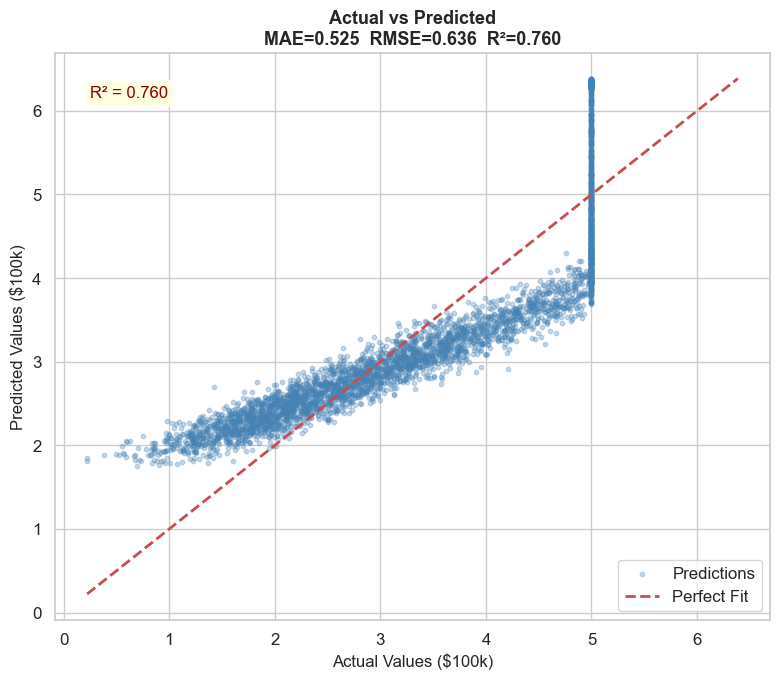

In [12]:
# Actual vs Predicted Scatter Plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10, label='Predictions')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
ax.set_xlabel('Actual Values ($100k)', fontsize=12)
ax.set_ylabel('Predicted Values ($100k)', fontsize=12)
ax.set_title(f'Actual vs Predicted\nMAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}', 
             fontsize=13, fontweight='bold')
ax.legend()
ax.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax.transAxes,
        fontsize=12, color='darkred', bbox=dict(boxstyle='round', facecolor='lightyellow'))
plt.tight_layout()
plt.show()


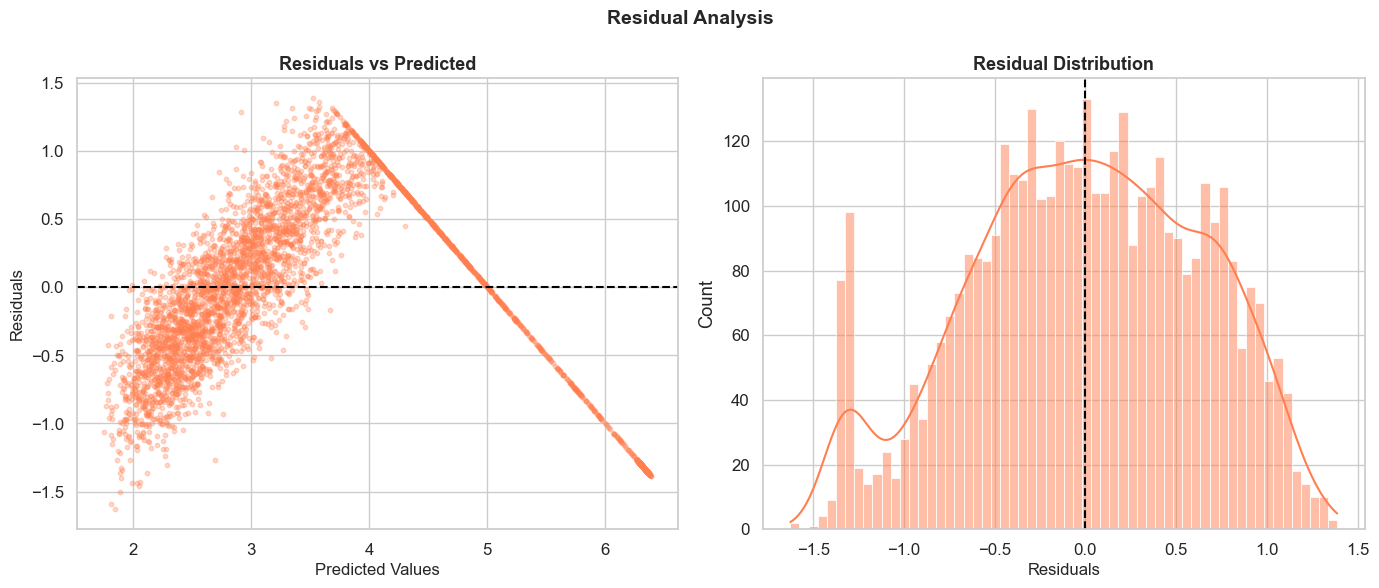

In [13]:
# Residual Analysis
residuals = y_test - y_pred
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(y_pred, residuals, alpha=0.3, color='coral', s=10)
ax1.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax1.set_xlabel('Predicted Values', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')

sns.histplot(residuals, kde=True, ax=ax2, color='coral', bins=60)
ax2.axvline(0, color='black', linestyle='--')
ax2.set_xlabel('Residuals', fontsize=12)
ax2.set_title('Residual Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


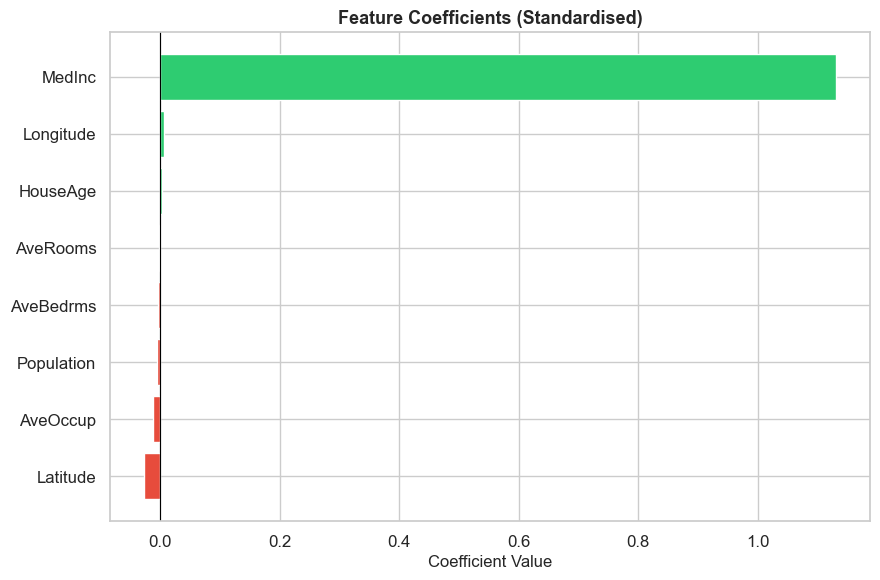


🟢 Green bars = positive effect on house price
🔴 Red bars   = negative effect on house price


In [14]:
# Feature Importance (Coefficients)
coef_sorted = coef_df.sort_values('Coefficient')
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Feature Coefficients (Standardised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n🟢 Green bars = positive effect on house price")
print("🔴 Red bars   = negative effect on house price")


## 8. Save Model <a id='8'></a>

In [15]:
# Save model + scaler as pickle
model_data = {'model': model, 'scaler': scaler, 'features': list(X.columns)}
with open('model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

# Save metrics as JSON
metrics = {"MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ Files saved:")
print("  • model.pkl    — trained model + scaler")
print("  • metrics.json — evaluation results")


✅ Files saved:
  • model.pkl    — trained model + scaler
  • metrics.json — evaluation results


## 9. Conclusion & Improvement Ideas <a id='9'></a>

### ✅ Results Summary
| Metric | Value |
|--------|-------|
| MAE    | 0.5248 (~$52,480 avg error) |
| RMSE   | 0.6357 |
| R²     | 0.7598 (76% variance explained) |

### 🔍 Key Findings
- **MedInc** (Median Income) is by far the strongest predictor of house price
- **Latitude** has a noticeable negative effect — northern California tends to be cheaper
- The model shows a slight non-linear pattern in residuals, suggesting room for improvement

### 🚀 Improvement Ideas
1. **Feature Engineering** — create interaction terms (MedInc × Latitude), log-transform skewed features
2. **Regularization** — try Ridge/Lasso regression to handle multicollinearity
3. **Non-linear models** — Random Forest or Gradient Boosting (XGBoost) would capture non-linear patterns
4. **Outlier removal** — properties > 4× IQR significantly hurt linear regression accuracy
5. **Polynomial Features** — add `MedInc²`, `HouseAge²` to capture curved relationships

### 📁 Deliverables
- `task1_ml_linear_regression.ipynb` — this notebook  
- `model.pkl` — saved model  
- `metrics.json` — evaluation metrics  
---
*Maincrafts Technology Internship | AI & Machine Learning Domain | Task 1 of 4*
